```
Author: Joshua Ashkinaze
Description: Bayesian model estimating P(American adult ever engaged in SSL).
             Combines chatbot usage prevalence with SSL-given-chatbot-use prevalence
             from two sources (Study 1 survey and the meta-analytic review).

Inputs:
    - survey_est.json:  Weighted any-SSL prevalence from Study 1 survey (N=392 LLM users)
    - meta_est.json:    SSL prevalence from the meta-analytic review (N=16,253 effective participants)
    - usage_est.json:   Chatbot usage prevalence from the Elon University survey (N=500)
    - ../data/clean/benchmarks.csv: U.S. adult behavior benchmarks for comparison

Outputs:
    - ../plots/pop_prevalence_posterior.pdf: Bayesian posterior for P(SSL | American adult)
    - ../plots/pop_benchmarks_model.pdf:     SSL estimate compared to other U.S. adult behaviors
```

In [2]:
####################
# Imports
####################

import json
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import cmdstanpy as csp
import matplotlib.pyplot as plt
import seaborn as sns
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "study1" else Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from helpers import make_aesthetic


Beta(2, 2) logit-normal approximation:
logit(theta) ~ Normal(mean = 0.0000, sd = 1.1357)

Stan prior:
alpha ~ normal(0.0000, 1.1357);

ssl_theta [P(SSL | chatbot user)] estimated from 2 source(s): Primary survey (Study 1b) (n = 392, p = 0.667, SE = 0.036); Meta-analysis estimate (Study 1a) (n = 260, p = 0.660, SE = 0.029).
chatbot_theta [P(chatbot | adult)] estimated from 2 source(s): Elon University poll (Jan 2025) (n = 939, p = 0.520, SE = 0.016); Real-Time Population Survey (Feb 2026) (n = 4,900, p = 0.579, SE = 0.011).



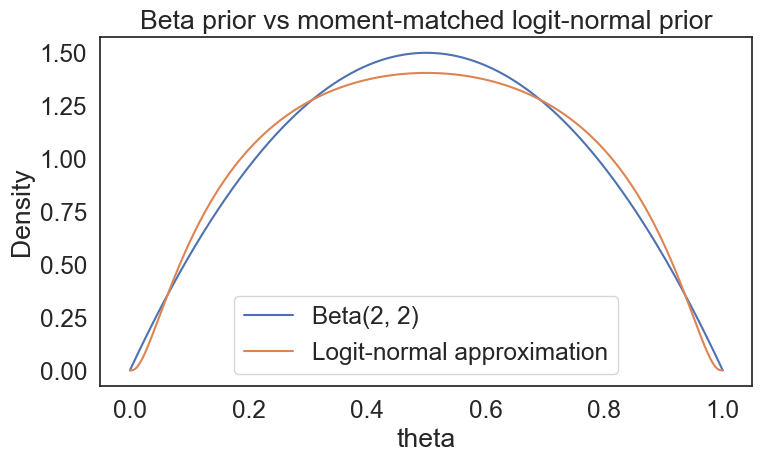

Analytic + prior posterior on logit scale:


,parameter,mean,sd
0,alpha_ssl,0.670265,0.100464
1,alpha_chatbot,0.240932,0.037022


Analytic no prior posterior on logit scale:


,parameter,mean,sd
0,alpha_ssl,0.675551,0.100859
1,alpha_chatbot,0.241188,0.037041


09:47:07 - cmdstanpy - INFO - compiling stan file /Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/ssl_pop_prevalence.stan to exe file /Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/ssl_pop_prevalence
09:47:11 - cmdstanpy - INFO - compiled model executable: /Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/ssl_pop_prevalence


...


Posterior summary for all four models:


,Model,Parameter,Mean,SD,Lower 95,Upper 95,Between-model SD
0,Analytic + prior,Chatbot use,0.5599,0.0091,0.5420,0.5778,0.0001
1,Analytic no prior,Chatbot use,0.5600,0.0091,0.5421,0.5778,0.0001
2,Stan + prior,Chatbot use,0.5600,0.0092,0.5415,0.5785,0.0001
3,Stan no prior,Chatbot use,0.5600,0.0092,0.5419,0.5777,0.0001
4,Analytic + prior,SSL conditional on chatbot use,0.6612,0.0225,0.6162,0.7044,0.0008
5,Analytic no prior,SSL conditional on chatbot use,0.6625,0.0225,0.6174,0.7053,0.0008
6,Stan + prior,SSL conditional on chatbot use,0.6610,0.0227,0.6152,0.7047,0.0008
7,Stan no prior,SSL conditional on chatbot use,0.6624,0.0229,0.6161,0.7060,0.0008
8,Analytic + prior,Population SSL prevalence,0.3702,0.0139,0.3426,0.3973,0.0005
9,Analytic no prior,Population SSL prevalence,0.3710,0.0140,0.3433,0.3982,0.0005


Saved raw summary to ../plots/pop_prevalence_four_models_summary.csv
Saved LaTeX summary to ../tables/pop_prevalence_four_models_summary.tex
Posterior summary for SSL conditional on chatbot use:


,Model,Parameter,Mean,SD,Lower 95,Upper 95,Between-model SD
0,Analytic + prior,SSL conditional on chatbot use,0.6612,0.0225,0.6162,0.7044,0.0008
1,Analytic no prior,SSL conditional on chatbot use,0.6625,0.0225,0.6174,0.7053,0.0008
2,Stan + prior,SSL conditional on chatbot use,0.6610,0.0227,0.6152,0.7047,0.0008
3,Stan no prior,SSL conditional on chatbot use,0.6624,0.0229,0.6161,0.7060,0.0008


Saved SSL theta LaTeX summary to ../tables/pop_prevalence_ssl_theta_summary.tex

Analytic + prior
----------------
chatbot_theta: mean = 0.560, 95% CI = (0.542, 0.578)
ssl_theta: mean = 0.661, 95% CI = (0.616, 0.704)
p_ssl: mean = 0.370, 95% CI = (0.343, 0.397)

Analytic no prior
-----------------
chatbot_theta: mean = 0.560, 95% CI = (0.542, 0.578)
ssl_theta: mean = 0.662, 95% CI = (0.617, 0.705)
p_ssl: mean = 0.371, 95% CI = (0.343, 0.398)

Stan + prior
------------
chatbot_theta: mean = 0.560, 95% CI = (0.542, 0.578)
ssl_theta: mean = 0.661, 95% CI = (0.615, 0.705)
p_ssl: mean = 0.370, 95% CI = (0.342, 0.398)

Stan no prior
-------------
chatbot_theta: mean = 0.560, 95% CI = (0.542, 0.578)
ssl_theta: mean = 0.662, 95% CI = (0.616, 0.706)
p_ssl: mean = 0.371, 95% CI = (0.343, 0.397)

Manuscript sentence: Analytic + prior
-------------------------------------
The posterior mean for population SSL prevalence was $M = 0.37$, 95\% credible interval $[0.34, 0.40]$. The component estimates

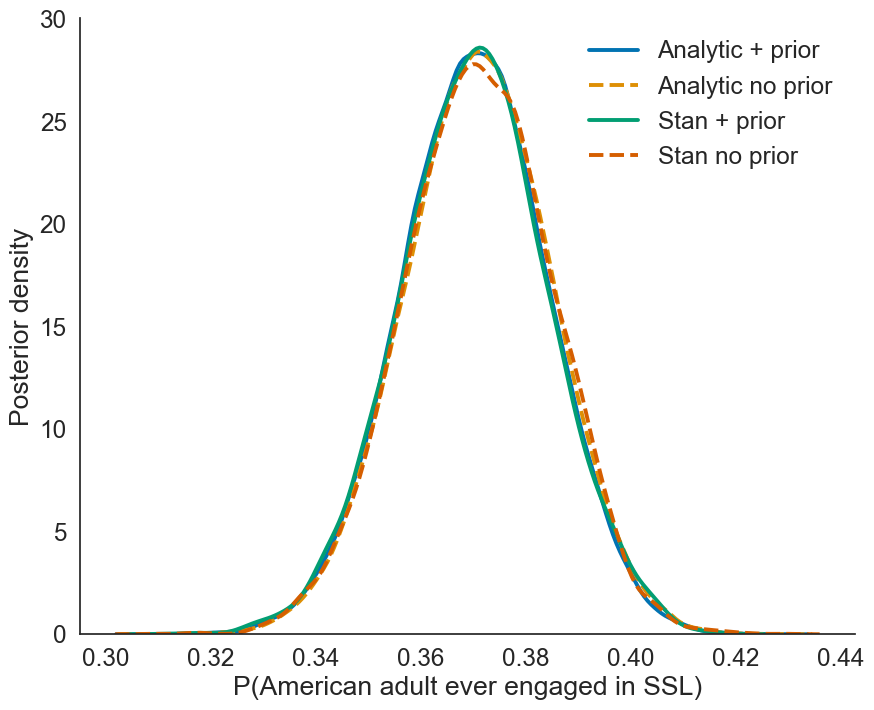

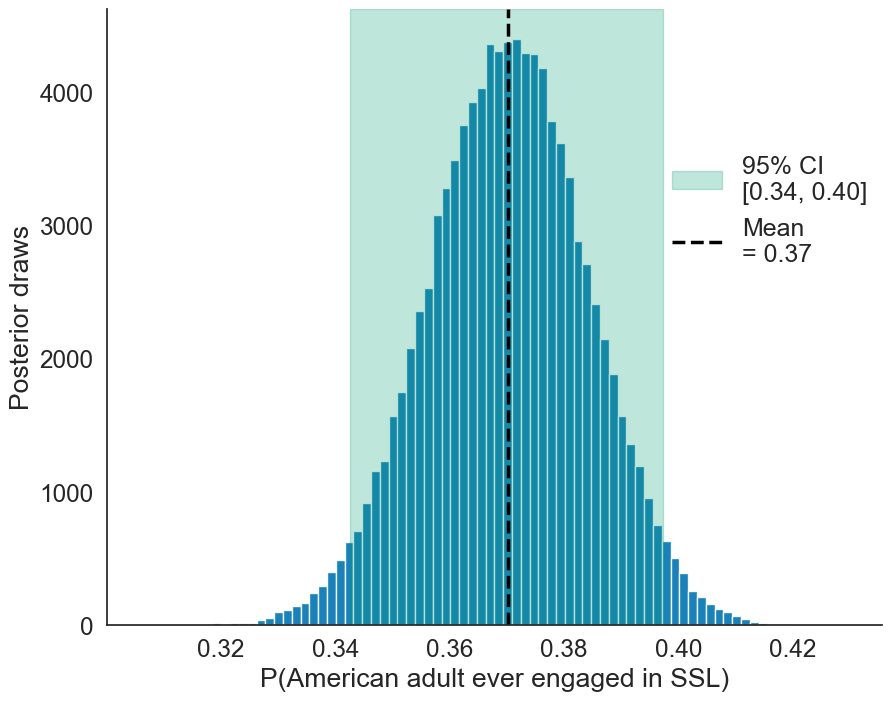

In [3]:
####################
# Imports
####################

import os
import random
import textwrap

import cmdstanpy as csp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.special import digamma, expit, logit, polygamma
from scipy.stats import beta, norm


####################
# Config
####################

SEED = 123
N_DRAWS = 100_000

BETA_A = 2
BETA_B = 2

N_GRID = 1_000
EPSILON = 1e-6

STAN_FILE = "ssl_pop_prevalence.stan"

PRIOR_PLOT_FILE = "moment_matched_prior.pdf"
ANALYTIC_PRIOR_PLOT_FILE = "../plots/pop_prevalence_analytic_prior.pdf"
FOUR_MODEL_PLOT_FILE = "../plots/pop_prevalence_four_models.pdf"

SUMMARY_FILE = "../plots/pop_prevalence_four_models_summary.csv"
SUMMARY_LATEX_FILE = "../tables/pop_prevalence_four_models_summary.tex"
SSL_THETA_LATEX_FILE = "../tables/pop_prevalence_ssl_theta_summary.tex"

STAN_CHAINS = 4
STAN_WARMUP = 1000
STAN_SAMPLING = 2000

np.random.seed(SEED)
random.seed(SEED)


####################
# Data
####################

ssl_usage = [
    {
        "name": "Primary survey (Study 1b)",
        "n": 392,
        "p": 0.667,
        "se": 0.035830,
    },
    {
        "name": "Meta-analysis estimate (Study 1a)",
        "n": 260,
        "p": 0.66,
        "se": 0.029,
    },
]

chatbot_usage = [
    {
        "name": "Elon University poll (Jan 2025)",
        "n": 939,
        "p": 0.52,
        "se": 0.032 / 1.96,
    },
    {
        "name": "Real-Time Population Survey (Feb 2026)",
        "n": 4900,
        "p": 0.578656027669195,
        "se": 1.09573505667904 / 100,
    },
]


####################
# Plot Style
####################

def make_default_palette(font_scale=1.4):
    """Set a simple plotting theme and return a color palette."""
    sns.set_theme(style="white", font_scale=font_scale)
    return sns.color_palette("colorblind", 8)


####################
# Data Helpers
####################

def resolve_entry(entry):
    """Fill in missing p or SE values."""
    resolved = dict(entry)

    if resolved.get("p") is None:
        resolved["p"] = resolved["k"] / resolved["n"]

    if resolved.get("se") is None:
        p = resolved["p"]
        n = resolved["n"]
        resolved["se"] = np.sqrt(p * (1 - p) / n)

    return resolved


def get_logit_se(p, se):
    """Compute delta-method SE for logit(p)."""
    return se / (p * (1 - p))


def get_logit_estimates(entries):
    """Convert probability estimates to logit estimates and SEs."""
    resolved_entries = [resolve_entry(entry) for entry in entries]

    logit_means = np.array([
        logit(entry["p"])
        for entry in resolved_entries
    ])

    logit_ses = np.array([
        get_logit_se(entry["p"], entry["se"])
        for entry in resolved_entries
    ])

    return logit_means, logit_ses


def print_source_summary(label, entries):
    """Print a compact source summary."""
    parts = []

    for entry in entries:
        resolved = resolve_entry(entry)
        parts.append(
            f"{resolved['name']} "
            f"(n = {resolved['n']:,}, "
            f"p = {resolved['p']:.3f}, "
            f"SE = {resolved['se']:.3f})"
        )

    source_text = "; ".join(parts)
    print(f"{label} estimated from {len(entries)} source(s): {source_text}.")


def make_stan_data(ssl_entries, chatbot_entries, prior_mean, prior_sd, use_prior):
    """Create Stan data from probability estimates."""
    ssl_logodds, ssl_logodds_se = get_logit_estimates(ssl_entries)
    chatbot_logodds, chatbot_logodds_se = get_logit_estimates(chatbot_entries)

    return {
        "N_ssl": len(ssl_logodds),
        "ssl_logodds": ssl_logodds.tolist(),
        "ssl_logodds_se": ssl_logodds_se.tolist(),
        "N_chatbot": len(chatbot_logodds),
        "chatbot_logodds": chatbot_logodds.tolist(),
        "chatbot_logodds_se": chatbot_logodds_se.tolist(),
        "prior_mean": prior_mean,
        "prior_sd": prior_sd,
        "use_prior": int(use_prior),
    }


####################
# Prior Approximation
####################

def get_logit_normal_approximation(beta_a, beta_b):
    """Match moments of logit(theta), where theta ~ Beta(a, b)."""
    prior_mean = digamma(beta_a) - digamma(beta_b)
    prior_variance = polygamma(1, beta_a) + polygamma(1, beta_b)
    prior_sd = np.sqrt(prior_variance)

    return prior_mean, prior_sd


def get_logit_normal_density(theta, prior_mean, prior_sd):
    """Get theta-density implied by logit(theta) ~ Normal(mean, sd)."""
    alpha = logit(theta)
    jacobian = 1 / (theta * (1 - theta))

    return norm.pdf(alpha, prior_mean, prior_sd) * jacobian


def plot_prior_approximation(beta_a, beta_b, prior_mean, prior_sd):
    """Plot Beta prior against moment-matched logit-normal prior."""
    theta_grid = np.linspace(EPSILON, 1 - EPSILON, N_GRID)

    beta_density = beta.pdf(theta_grid, beta_a, beta_b)
    approx_density = get_logit_normal_density(
        theta_grid,
        prior_mean,
        prior_sd,
    )

    plt.figure(figsize=(8, 5))
    plt.plot(theta_grid, beta_density, label=f"Beta({beta_a}, {beta_b})")
    plt.plot(theta_grid, approx_density, label="Logit-normal approximation")
    plt.xlabel("theta")
    plt.ylabel("Density")
    plt.title("Beta prior vs moment-matched logit-normal prior")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PRIOR_PLOT_FILE)
    plt.show()


####################
# Analytic Gaussian Model
####################

def combine_gaussian_estimates_with_prior(logit_means, logit_ses, prior_mean, prior_sd):
    """Combine Gaussian estimates with a Gaussian prior."""
    prior_precision = 1 / prior_sd**2
    data_precisions = 1 / logit_ses**2

    posterior_variance = 1 / (prior_precision + data_precisions.sum())
    posterior_mean = posterior_variance * (
        prior_mean * prior_precision
        + np.sum(logit_means * data_precisions)
    )
    posterior_sd = np.sqrt(posterior_variance)

    return posterior_mean, posterior_sd


def combine_gaussian_estimates_no_prior(logit_means, logit_ses):
    """Combine Gaussian estimates using inverse-variance weighting only."""
    data_precisions = 1 / logit_ses**2

    posterior_variance = 1 / data_precisions.sum()
    posterior_mean = posterior_variance * np.sum(logit_means * data_precisions)
    posterior_sd = np.sqrt(posterior_variance)

    return posterior_mean, posterior_sd


def combine_gaussian_estimates(logit_means, logit_ses, prior_mean, prior_sd, use_prior):
    """Combine Gaussian estimates with or without a Gaussian prior."""
    if use_prior:
        return combine_gaussian_estimates_with_prior(
            logit_means,
            logit_ses,
            prior_mean,
            prior_sd,
        )

    return combine_gaussian_estimates_no_prior(
        logit_means,
        logit_ses,
    )


def run_analytic_model(
    ssl_entries,
    chatbot_entries,
    prior_mean,
    prior_sd,
    use_prior,
    n_draws,
    seed,
):
    """Run closed-form Gaussian updating and Monte Carlo propagation."""
    rng = np.random.default_rng(seed)

    ssl_logit_means, ssl_logit_ses = get_logit_estimates(ssl_entries)
    chatbot_logit_means, chatbot_logit_ses = get_logit_estimates(chatbot_entries)

    ssl_alpha_mean, ssl_alpha_sd = combine_gaussian_estimates(
        ssl_logit_means,
        ssl_logit_ses,
        prior_mean,
        prior_sd,
        use_prior,
    )

    chatbot_alpha_mean, chatbot_alpha_sd = combine_gaussian_estimates(
        chatbot_logit_means,
        chatbot_logit_ses,
        prior_mean,
        prior_sd,
        use_prior,
    )

    ssl_alpha_draws = rng.normal(ssl_alpha_mean, ssl_alpha_sd, n_draws)
    chatbot_alpha_draws = rng.normal(chatbot_alpha_mean, chatbot_alpha_sd, n_draws)

    draws = pd.DataFrame({
        "alpha_ssl": ssl_alpha_draws,
        "alpha_chatbot": chatbot_alpha_draws,
        "ssl_theta": expit(ssl_alpha_draws),
        "chatbot_theta": expit(chatbot_alpha_draws),
    })

    draws["p_ssl"] = draws["ssl_theta"] * draws["chatbot_theta"]

    logit_summary = pd.DataFrame([
        {
            "parameter": "alpha_ssl",
            "mean": ssl_alpha_mean,
            "sd": ssl_alpha_sd,
        },
        {
            "parameter": "alpha_chatbot",
            "mean": chatbot_alpha_mean,
            "sd": chatbot_alpha_sd,
        },
    ])

    return draws, logit_summary


####################
# Stan Model
####################

stan_code = """
data {
  int<lower=1> N_ssl;
  vector[N_ssl] ssl_logodds;
  vector<lower=0>[N_ssl] ssl_logodds_se;

  int<lower=1> N_chatbot;
  vector[N_chatbot] chatbot_logodds;
  vector<lower=0>[N_chatbot] chatbot_logodds_se;

  real prior_mean;
  real<lower=0> prior_sd;
  int<lower=0, upper=1> use_prior;
}

parameters {
  real alpha_ssl;
  real alpha_chatbot;
}

transformed parameters {
  real<lower=0, upper=1> ssl_theta = inv_logit(alpha_ssl);
  real<lower=0, upper=1> chatbot_theta = inv_logit(alpha_chatbot);
}

model {
  if (use_prior == 1) {
    alpha_ssl ~ normal(prior_mean, prior_sd);
    alpha_chatbot ~ normal(prior_mean, prior_sd);
  }

  ssl_logodds ~ normal(alpha_ssl, ssl_logodds_se);
  chatbot_logodds ~ normal(alpha_chatbot, chatbot_logodds_se);
}

generated quantities {
  real<lower=0, upper=1> p_ssl = chatbot_theta * ssl_theta;
}
"""


def write_stan_model(stan_file, stan_code):
    """Write Stan model to disk."""
    with open(stan_file, "w") as file:
        file.write(stan_code)


def compile_stan_model():
    """Compile the Stan model once."""
    write_stan_model(STAN_FILE, stan_code)
    return csp.CmdStanModel(stan_file=STAN_FILE)


def run_stan_model(model, stan_data):
    """Sample from the Stan model."""
    fit = model.sample(
        data=stan_data,
        chains=STAN_CHAINS,
        iter_warmup=STAN_WARMUP,
        iter_sampling=STAN_SAMPLING,
        seed=SEED,
    )

    return fit.draws_pd()


####################
# Posterior Helpers
####################

def summarize_draw_array(name, values, interval=0.95):
    """Summarize a single array of posterior draws."""
    lower_q = (1 - interval) / 2
    upper_q = 1 - lower_q

    return {
        "parameter": name,
        "mean": values.mean(),
        "sd": values.std(),
        f"lower_{int(interval * 100)}": np.quantile(values, lower_q),
        f"upper_{int(interval * 100)}": np.quantile(values, upper_q),
    }


def summarize_draws(draws, parameters, interval=0.95):
    """Summarize posterior draws."""
    rows = []

    for parameter in parameters:
        values = draws[parameter].to_numpy()
        rows.append(summarize_draw_array(parameter, values, interval))

    return pd.DataFrame(rows)


def summarize_model_draws(model_name, draws):
    """Summarize one model's posterior draws."""
    summary = summarize_draws(
        draws,
        parameters=[
            "chatbot_theta",
            "ssl_theta",
            "p_ssl",
            "alpha_chatbot",
            "alpha_ssl",
        ],
    )

    summary.insert(0, "model", model_name)
    return summary


def print_manuscript_values(label, draws):
    """Print key posterior values."""
    print()
    print(label)
    print("-" * len(label))

    for name in ["chatbot_theta", "ssl_theta", "p_ssl"]:
        values = draws[name].to_numpy()
        mean = values.mean()
        lower, upper = np.quantile(values, [0.025, 0.975])

        print(
            f"{name}: "
            f"mean = {mean:.3f}, "
            f"95% CI = ({lower:.3f}, {upper:.3f})"
        )


def print_manuscript_sentence(label, draws):
    """Print a manuscript-ready sentence."""
    chatbot_values = draws["chatbot_theta"].to_numpy()
    ssl_values = draws["ssl_theta"].to_numpy()
    population_values = draws["p_ssl"].to_numpy()

    chatbot_mean = chatbot_values.mean()
    chatbot_lower, chatbot_upper = np.quantile(chatbot_values, [0.025, 0.975])

    ssl_mean = ssl_values.mean()
    ssl_lower, ssl_upper = np.quantile(ssl_values, [0.025, 0.975])

    population_mean = population_values.mean()
    population_lower, population_upper = np.quantile(population_values, [0.025, 0.975])

    print()
    print(f"Manuscript sentence: {label}")
    print("-" * (21 + len(label)))
    print(
        "The posterior mean for population SSL prevalence was "
        f"$M = {population_mean:.2f}$, "
        f"95\\% credible interval "
        f"$[{population_lower:.2f}, {population_upper:.2f}]$. "
        "The component estimates were "
        f"$\\theta_{{\\mathrm{{chatbot}}}} = {chatbot_mean:.2f}$, "
        f"95\\% credible interval "
        f"$[{chatbot_lower:.2f}, {chatbot_upper:.2f}]$, "
        "and "
        f"$\\theta_{{\\mathrm{{SSL}}}} = {ssl_mean:.2f}$, "
        f"95\\% credible interval "
        f"$[{ssl_lower:.2f}, {ssl_upper:.2f}]$."
    )


####################
# Summary Table Helpers
####################

def clean_parameter_label(parameter):
    """Make parameter labels display- and LaTeX-safe."""
    labels = {
        "chatbot_theta": "Chatbot use",
        "ssl_theta": "SSL conditional on chatbot use",
        "p_ssl": "Population SSL prevalence",
        "alpha_chatbot": "Chatbot use log odds",
        "alpha_ssl": "SSL conditional log odds",
    }

    return labels.get(parameter, parameter.replace("_", " "))


def make_summary_table(model_draws):
    """Create a clean posterior summary table."""
    summary = pd.concat(
        [
            summarize_model_draws(model_name, draws)
            for model_name, draws in model_draws.items()
        ],
        ignore_index=True,
    )

    summary["between_model_sd"] = (
        summary
        .groupby("parameter")["mean"]
        .transform("std")
    )

    parameter_order = [
        "chatbot_theta",
        "ssl_theta",
        "p_ssl",
        "alpha_chatbot",
        "alpha_ssl",
    ]

    model_order = [
        "Analytic + prior",
        "Analytic no prior",
        "Stan + prior",
        "Stan no prior",
    ]

    summary["parameter"] = pd.Categorical(
        summary["parameter"],
        categories=parameter_order,
        ordered=True,
    )

    summary["model"] = pd.Categorical(
        summary["model"],
        categories=model_order,
        ordered=True,
    )

    summary = (
        summary
        .sort_values(["parameter", "model"])
        .reset_index(drop=True)
    )

    return summary


def make_display_summary(summary):
    """Create a rounded summary for display."""
    display_summary = summary.copy()

    display_summary["parameter"] = (
        display_summary["parameter"]
        .astype(str)
        .map(clean_parameter_label)
    )

    display_summary = display_summary.rename(
        columns={
            "model": "Model",
            "parameter": "Parameter",
            "mean": "Mean",
            "sd": "SD",
            "lower_95": "Lower 95",
            "upper_95": "Upper 95",
            "between_model_sd": "Between-model SD",
        }
    )

    numeric_columns = [
        "Mean",
        "SD",
        "Lower 95",
        "Upper 95",
        "Between-model SD",
    ]

    display_summary[numeric_columns] = display_summary[numeric_columns].round(4)

    return display_summary


def write_latex_table(display_summary, latex_file, caption, label):
    """Write a clean LaTeX table."""
    latex = display_summary.to_latex(
        index=False,
        escape=True,
        caption=caption,
        label=label,
        float_format="%.4f",
    )

    with open(latex_file, "w") as file:
        file.write(latex)


####################
# Plot Helpers
####################

def make_long_draws(model_draws):
    """Stack model draws into a long dataframe."""
    rows = []

    for model_name, draws in model_draws.items():
        model_df = pd.DataFrame({
            "model": model_name,
            "p_ssl": draws["p_ssl"].to_numpy(),
        })
        rows.append(model_df)

    return pd.concat(rows, ignore_index=True)


def plot_four_model_comparison(model_draws, palette):
    """Plot posterior densities for all four models."""
    plot_df = make_long_draws(model_draws)

    fig, ax = plt.subplots(figsize=(10, 8))

    model_order = [
        "Analytic + prior",
        "Analytic no prior",
        "Stan + prior",
        "Stan no prior",
    ]

    for i, model_name in enumerate(model_order):
        subset = plot_df[plot_df["model"].eq(model_name)]

        linestyle = "-"
        if "no prior" in model_name:
            linestyle = "--"

        sns.kdeplot(
            data=subset,
            x="p_ssl",
            ax=ax,
            label=model_name,
            linewidth=2.8,
            linestyle=linestyle,
            color=palette[i],
        )

    ax.set_xlabel("P(American adult ever engaged in SSL)")
    ax.set_ylabel("Posterior density")
    ax.legend(frameon=False)
    sns.despine(ax=ax)

    fig.savefig(FOUR_MODEL_PLOT_FILE, dpi=300, bbox_inches="tight")
    plt.show()


def plot_analytic_prior_posterior(draws, palette):
    """Plot posterior histogram for analytic model with prior."""
    p_ssl_samples = draws["p_ssl"].to_numpy()

    mean_val = p_ssl_samples.mean()
    lo95, hi95 = np.quantile(p_ssl_samples, [0.025, 0.975])

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.hist(
        p_ssl_samples,
        bins=80,
        color=palette[0],
        edgecolor="white",
        alpha=0.9,
    )

    ax.axvspan(
        lo95,
        hi95,
        alpha=0.25,
        color=palette[2],
        label=f"95% CI\n[{lo95:.2f}, {hi95:.2f}]",
    )

    ax.axvline(
        mean_val,
        color="black",
        lw=2.5,
        linestyle="--",
        label=f"Mean\n= {mean_val:.2f}",
    )

    ax.set_xlabel("P(American adult ever engaged in SSL)")
    ax.set_ylabel("Posterior draws")
    ax.legend(frameon=False, fontsize=18, bbox_to_anchor=(0.7, 0.8))
    sns.despine(ax=ax)

    fig.savefig(
        ANALYTIC_PRIOR_PLOT_FILE,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


####################
# Run
####################

os.makedirs("../plots", exist_ok=True)

palette = make_default_palette(font_scale=1.6)

prior_mean, prior_sd = get_logit_normal_approximation(BETA_A, BETA_B)

print(f"Beta({BETA_A}, {BETA_B}) logit-normal approximation:")
print(f"logit(theta) ~ Normal(mean = {prior_mean:.4f}, sd = {prior_sd:.4f})")
print()

print("Stan prior:")
print(f"alpha ~ normal({prior_mean:.4f}, {prior_sd:.4f});")
print()

print_source_summary("ssl_theta [P(SSL | chatbot user)]", ssl_usage)
print_source_summary("chatbot_theta [P(chatbot | adult)]", chatbot_usage)
print()

plot_prior_approximation(BETA_A, BETA_B, prior_mean, prior_sd)


####################
# Analytic Models
####################

analytic_prior_draws, analytic_prior_logit_summary = run_analytic_model(
    ssl_entries=ssl_usage,
    chatbot_entries=chatbot_usage,
    prior_mean=prior_mean,
    prior_sd=prior_sd,
    use_prior=True,
    n_draws=N_DRAWS,
    seed=SEED,
)

analytic_no_prior_draws, analytic_no_prior_logit_summary = run_analytic_model(
    ssl_entries=ssl_usage,
    chatbot_entries=chatbot_usage,
    prior_mean=prior_mean,
    prior_sd=prior_sd,
    use_prior=False,
    n_draws=N_DRAWS,
    seed=SEED + 1,
)

print("Analytic + prior posterior on logit scale:")
display(analytic_prior_logit_summary)

print("Analytic no prior posterior on logit scale:")
display(analytic_no_prior_logit_summary)


####################
# Stan Models
####################

stan_model = compile_stan_model()

stan_prior_data = make_stan_data(
    ssl_entries=ssl_usage,
    chatbot_entries=chatbot_usage,
    prior_mean=prior_mean,
    prior_sd=prior_sd,
    use_prior=True,
)

stan_no_prior_data = make_stan_data(
    ssl_entries=ssl_usage,
    chatbot_entries=chatbot_usage,
    prior_mean=prior_mean,
    prior_sd=prior_sd,
    use_prior=False,
)

print("Stan data with prior:")
print(stan_prior_data)
print()

print("Stan data no prior:")
print(stan_no_prior_data)
print()

stan_prior_draws = run_stan_model(
    model=stan_model,
    stan_data=stan_prior_data,
)

stan_no_prior_draws = run_stan_model(
    model=stan_model,
    stan_data=stan_no_prior_data,
)


####################
# Summaries
####################

model_draws = {
    "Analytic + prior": analytic_prior_draws,
    "Analytic no prior": analytic_no_prior_draws,
    "Stan + prior": stan_prior_draws,
    "Stan no prior": stan_no_prior_draws,
}

summary = make_summary_table(model_draws)
display_summary = make_display_summary(summary)

print("Posterior summary for all four models:")
display(display_summary)

summary.to_csv(SUMMARY_FILE, index=False)
print(f"Saved raw summary to {SUMMARY_FILE}")

write_latex_table(
    display_summary=display_summary,
    latex_file=SUMMARY_LATEX_FILE,
    caption=(
        "Posterior summaries for the four Bayesian prevalence models. "
        f"Filename: {os.path.basename(SUMMARY_LATEX_FILE)}."
    ),
    label="tab:pop-prevalence-four-models",
)

print(f"Saved LaTeX summary to {SUMMARY_LATEX_FILE}")


####################
# SSL Theta Summary Only
####################

ssl_theta_summary = (
    summary
    .query("parameter == 'ssl_theta'")
    .reset_index(drop=True)
)

ssl_theta_display = make_display_summary(ssl_theta_summary)

print("Posterior summary for SSL conditional on chatbot use:")
display(ssl_theta_display)

write_latex_table(
    display_summary=ssl_theta_display,
    latex_file=SSL_THETA_LATEX_FILE,
    caption=(
        "Posterior summaries for the conditional prevalence of SSL among chatbot users. "
        f"Filename: {os.path.basename(SSL_THETA_LATEX_FILE)}."
    ),
    label="tab:pop-prevalence-ssl-theta",
)

print(f"Saved SSL theta LaTeX summary to {SSL_THETA_LATEX_FILE}")


####################
# Manuscript Values
####################

for model_name, draws in model_draws.items():
    print_manuscript_values(model_name, draws)

print_manuscript_sentence("Analytic + prior", analytic_prior_draws)
print_manuscript_sentence("Stan + prior", stan_prior_draws)


####################
# Plots
####################

plot_four_model_comparison(model_draws, palette)

plot_analytic_prior_posterior(
    draws=analytic_prior_draws,
    palette=palette,
)

In [67]:
print(model.code())


data {
  int<lower=1> N_ssl;
  vector[N_ssl]          ssl_logodds;
  vector<lower=0>[N_ssl] ssl_logodds_se;

  int<lower=1> N_chatbot;
  vector[N_chatbot]          chatbot_logodds;
  vector<lower=0>[N_chatbot] chatbot_logodds_se;
}

parameters {
  real alpha_ssl;
  real alpha_chatbot;
}

transformed parameters {
  real<lower=0, upper=1> ssl_theta     = inv_logit(alpha_ssl);
  real<lower=0, upper=1> chatbot_theta = inv_logit(alpha_chatbot);
}

model {
  ssl_theta     ~ beta(2, 2);
  chatbot_theta ~ beta(2, 2);

  ssl_logodds     ~ normal(alpha_ssl,     ssl_logodds_se);
  chatbot_logodds ~ normal(alpha_chatbot, chatbot_logodds_se);
}

generated quantities {
  real<lower=0, upper=1> p_ssl = chatbot_theta * ssl_theta;
}



/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_75305/2349081895.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="percentage", y="short_version_wrap", data=use, palette=colors, ax=ax)


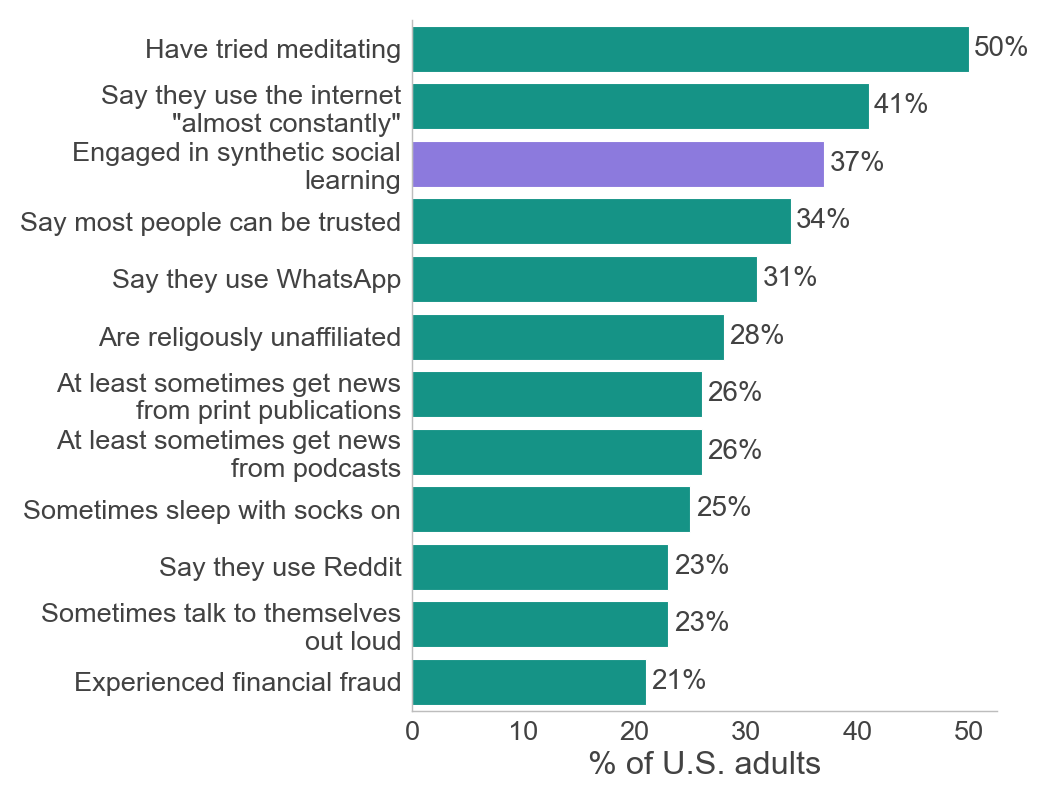

In [50]:
####################
# Plot 2: Benchmarks
####################


mypal = make_aesthetic(font_scale=1.3)

bench = pd.read_csv("../data/clean/benchmarks.csv")
use = bench[bench["flag(positive)"] > 0].copy()

ssl_pct = float(np.round(mean_val * 100, 0))
use["percentage"] = use["percentage"].apply(lambda x: ssl_pct if x < 0 else x)
use = use.dropna(subset=["short_version"])
use["short_version_wrap"] = use["short_version"].apply(lambda x: wrap_text(x, width=30))
use = use.sort_values("percentage", ascending=False)

colors = [
    mypal[1] if "synthetic social learning" in str(row["short_version"]).lower() else mypal[0]
    for _, row in use.iterrows()
]

fig, ax = plt.subplots(figsize=(10.5, 8))
sns.barplot(x="percentage", y="short_version_wrap", data=use, palette=colors, ax=ax)
ax.set_xlabel("% of U.S. adults")
ax.set_ylabel("")

for i, (idx, row) in enumerate(use.iterrows()):
    ax.text(row["percentage"] + 0.5, i, f"{row['percentage']:.0f}%",
            va="center", fontsize=20)

sns.despine(ax=ax)
fig.savefig("../plots/pop_benchmarks_model.pdf", dpi=300, bbox_inches="tight")
plt.show()
